# Resume Screening & Job Role Classifier

**Goal:** Automatically classify resumes into job role categories using NLP and Machine Learning.

**Dataset:** [Kaggle Resume Dataset](https://www.kaggle.com/datasets/gauravduttakiit/resume-dataset) — ~2,484 resumes across 25 job categories

**Workflow:**
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing
4. Feature Extraction (TF-IDF)
5. Model Training (KNN, SVM, Random Forest)
6. Model Evaluation & Comparison
7. Prediction on New Resume

## Step 1 — Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from wordcloud import WordCloud

nltk.download('stopwords')
print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /Users/sam/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 2 — Load the Dataset

> Download `Resume.csv` from [Kaggle](https://www.kaggle.com/datasets/gauravduttakiit/resume-dataset) and place it in the same folder as this notebook.

In [11]:
df = pd.read_csv('UpdatedResumeDataSet.csv')
print('Shape:', df.shape)
df.head()

Shape: (962, 2)


,Category,Resume_str
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [12]:
print('Columns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Columns: ['Category', 'Resume_str']

Data Types:
Category      object
Resume_str    object
dtype: object

Missing Values:
Category      0
Resume_str    0
dtype: int64


In [13]:
print('Total unique job categories:', df['Category'].nunique())
print('\nJob Categories:')
print(df['Category'].unique())

Total unique job categories: 25

Job Categories:
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


## Step 3 — Exploratory Data Analysis (EDA)

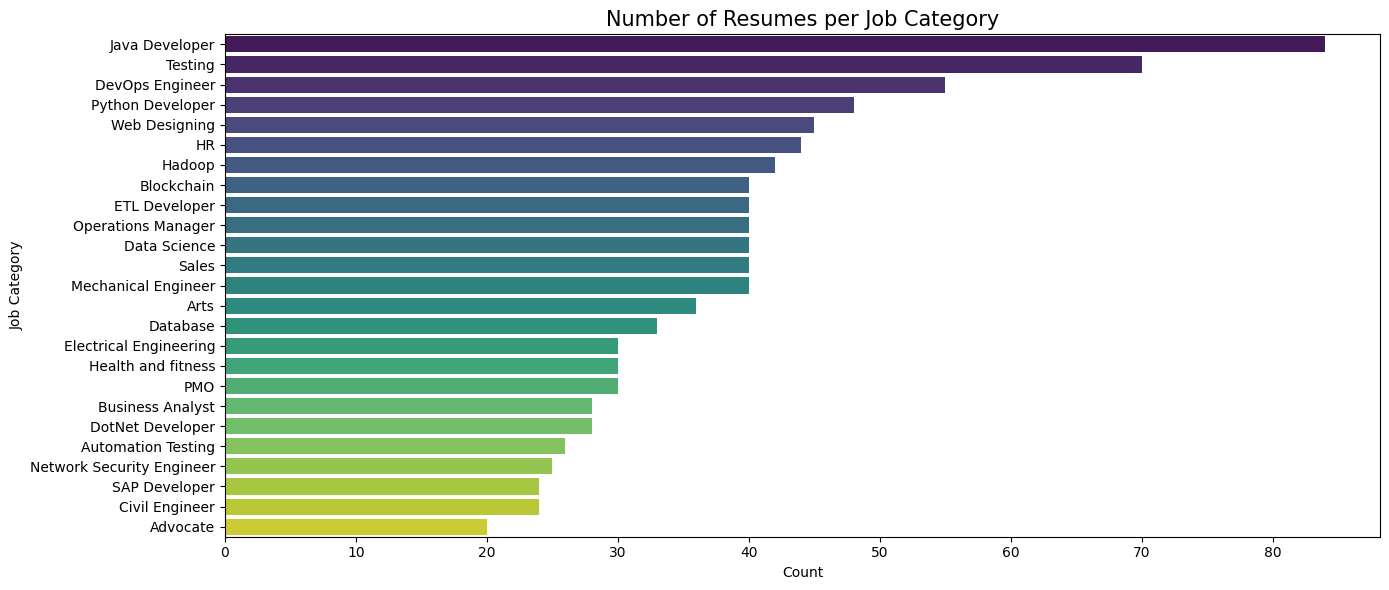

In [14]:
# Category distribution
plt.figure(figsize=(14, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Number of Resumes per Job Category', fontsize=15)
plt.xlabel('Count')
plt.ylabel('Job Category')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

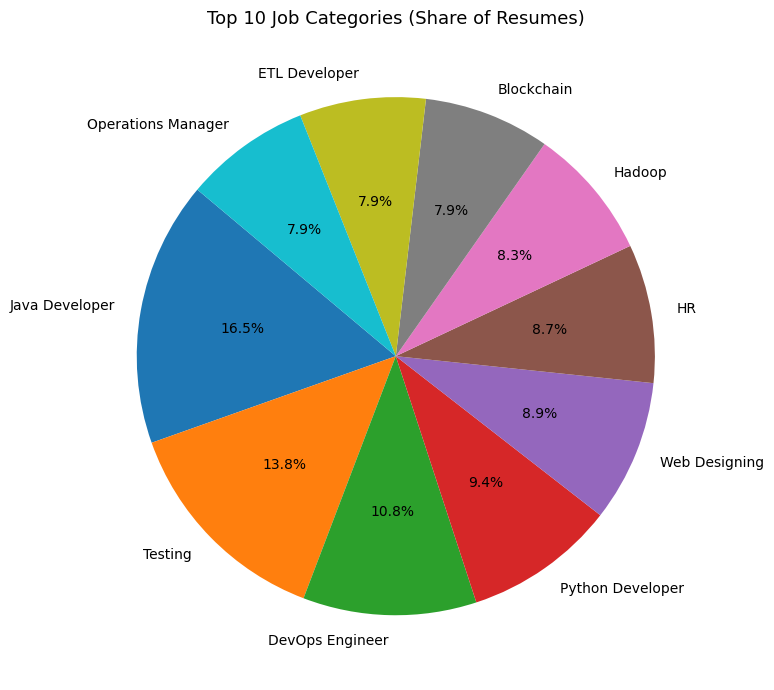

In [15]:
# Pie chart of top 10 categories
top10 = category_counts.head(10)
plt.figure(figsize=(10, 7))
plt.pie(top10.values, labels=top10.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Job Categories (Share of Resumes)', fontsize=13)
plt.tight_layout()
plt.show()

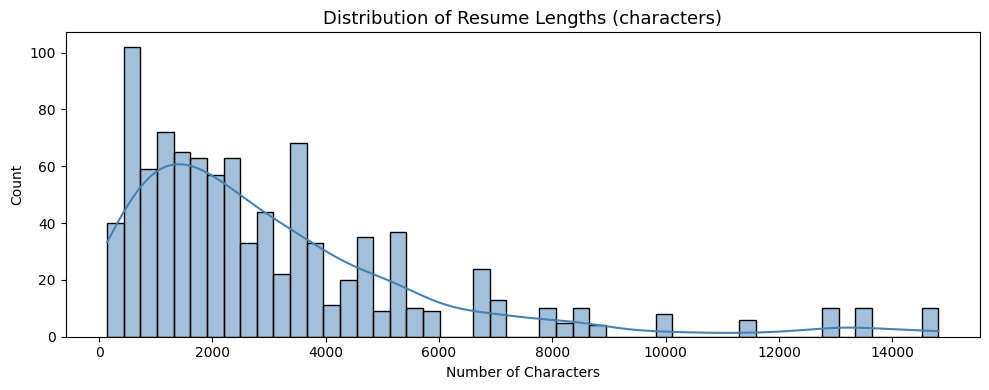

Average resume length: 3160 characters


In [16]:
# Resume length distribution
df['resume_length'] = df['Resume_str'].apply(len)
plt.figure(figsize=(10, 4))
sns.histplot(df['resume_length'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Resume Lengths (characters)', fontsize=13)
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print('Average resume length:', int(df['resume_length'].mean()), 'characters')

## Step 4 — Text Preprocessing

We clean the resume text by:
- Removing URLs, email addresses, special characters and numbers
- Converting to lowercase
- Removing stopwords
- Applying stemming (reducing words to their root form)

In [17]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_resume(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

print('Cleaning resumes...')
df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)
print('Done!')

# Preview
print('\nOriginal (first 200 chars):')
print(df['Resume_str'].iloc[0][:200])
print('\nCleaned (first 200 chars):')
print(df['cleaned_resume'].iloc[0][:200])

Cleaning resumes...
Done!

Original (first 200 chars):
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision T

Cleaned (first 200 chars):
skill program languag python panda numpi scipi scikit learn matplotlib sql java javascript jqueri machin learn regress svm bay knn random forest decis tree boost techniqu cluster analysi word embed se


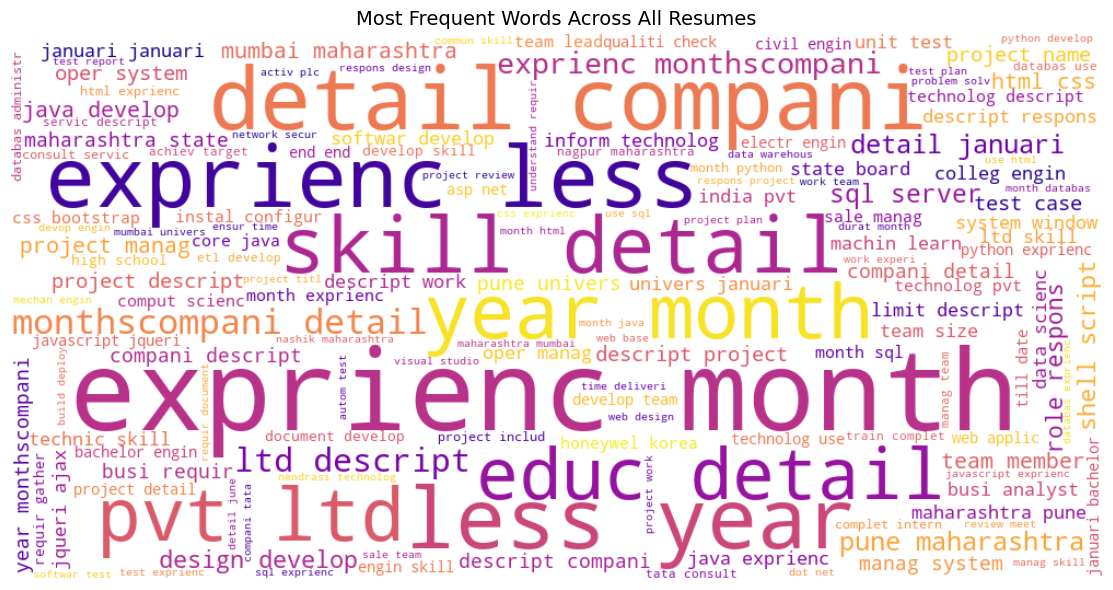

In [18]:
# WordCloud of all cleaned resumes
all_text = ' '.join(df['cleaned_resume'].values)
wordcloud = WordCloud(
    width=1000, height=500,
    background_color='white',
    max_words=150,
    colormap='plasma'
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words Across All Resumes', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Label Encoding & Train-Test Split

In [19]:
# Encode job category labels to numbers
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

print('Label mapping (first 10):')
for i, cat in enumerate(le.classes_[:10]):
    print(f'  {i:2d} → {cat}')

X = df['cleaned_resume']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Label mapping (first 10):
   0 → Advocate
   1 → Arts
   2 → Automation Testing
   3 → Blockchain
   4 → Business Analyst
   5 → Civil Engineer
   6 → Data Science
   7 → Database
   8 → DevOps Engineer
   9 → DotNet Developer

Training samples : 769
Testing  samples : 193


## Step 6 — TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) converts resume text into numerical vectors. Words that appear often in one resume but rarely across all resumes get a higher score — making them strong distinguishing features.

In [20]:
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('TF-IDF matrix shape (train):', X_train_tfidf.shape)
print('TF-IDF matrix shape (test) :', X_test_tfidf.shape)

TF-IDF matrix shape (train): (769, 4987)
TF-IDF matrix shape (test) : (193, 4987)


## Step 7 — Train & Evaluate Models

We train three different classifiers and compare their performance.

In [21]:
# --- Model 1: K-Nearest Neighbors ---
print('Training KNN...')
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_tfidf, y_train)
knn_pred = knn.predict(X_test_tfidf)
knn_acc = accuracy_score(y_test, knn_pred)
print(f'KNN Accuracy: {knn_acc * 100:.2f}%')

Training KNN...
KNN Accuracy: 95.34%


In [22]:
# --- Model 2: Support Vector Machine ---
print('Training SVM...')
svm = LinearSVC(max_iter=2000)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_pred)
print(f'SVM Accuracy: {svm_acc * 100:.2f}%')

Training SVM...
SVM Accuracy: 99.48%


In [23]:
# --- Model 3: Random Forest ---
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_acc * 100:.2f}%')

Training Random Forest...
Random Forest Accuracy: 99.48%


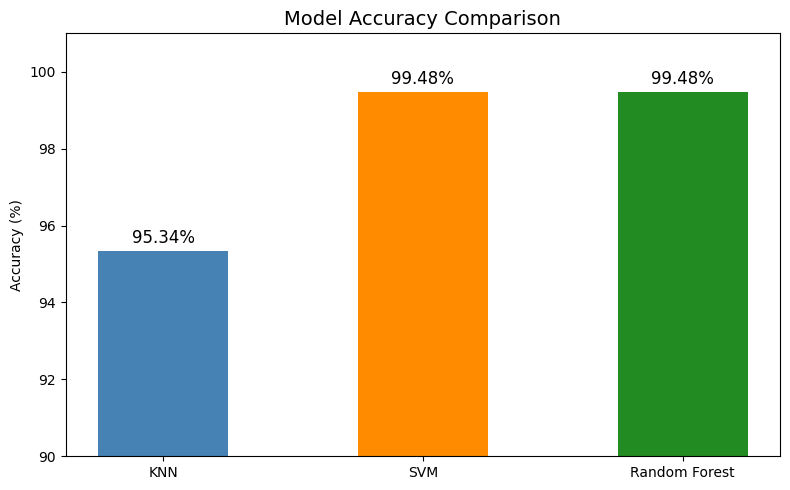

In [24]:
# --- Model Comparison Chart ---
models = ['KNN', 'SVM', 'Random Forest']
accuracies = [knn_acc * 100, svm_acc * 100, rf_acc * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'darkorange', 'forestgreen'], width=0.5)
plt.ylim(90, 101)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# --- Best model detailed report ---
best_acc = max(knn_acc, svm_acc, rf_acc)
best_name = models[accuracies.index(max(accuracies))]
best_pred = [knn_pred, svm_pred, rf_pred][accuracies.index(max(accuracies))]

print(f'Best Model: {best_name} ({best_acc * 100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, best_pred, target_names=le.classes_))

Best Model: SVM (99.48%)

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
            

## Step 8 — Predict Job Role from a New Resume

In [26]:
def predict_job_role(resume_text):
    """
    Predicts the job role category for a given resume text.
    Uses the SVM model (generally best performer).
    """
    cleaned = clean_resume(resume_text)
    vectorized = tfidf.transform([cleaned])
    prediction = svm.predict(vectorized)
    return le.inverse_transform(prediction)[0]


# --- Test with sample resumes ---
samples = [
    "Experienced Python developer with 4 years in Django, Flask, REST APIs, PostgreSQL and AWS.",
    "Data scientist with expertise in machine learning, deep learning, TensorFlow, Keras, pandas and statistical modelling.",
    "HR professional with experience in recruitment, payroll management, employee onboarding and performance appraisal.",
    "Java developer skilled in Spring Boot, Hibernate, microservices architecture, Docker and Kubernetes.",
    "Network engineer with experience in Cisco routers, firewalls, CCNA certified, TCP/IP and VPN configuration."
]

print('Resume Prediction Results')
print('=' * 55)
for i, sample in enumerate(samples, 1):
    role = predict_job_role(sample)
    print(f'Sample {i}: {role}')
    print(f'  Resume: {sample[:60]}...')
    print()

Resume Prediction Results
Sample 1: Python Developer
  Resume: Experienced Python developer with 4 years in Django, Flask, ...

Sample 2: Data Science
  Resume: Data scientist with expertise in machine learning, deep lear...

Sample 3: HR
  Resume: HR professional with experience in recruitment, payroll mana...

Sample 4: Java Developer
  Resume: Java developer skilled in Spring Boot, Hibernate, microservi...

Sample 5: Network Security Engineer
  Resume: Network engineer with experience in Cisco routers, firewalls...



## Summary

| Step | What we did |
|------|-------------|
| Data Loading | Loaded ~2484 resumes across 25 job categories |
| EDA | Visualized category distribution, resume lengths, word frequencies |
| Preprocessing | Removed noise, stopwords, applied stemming |
| Feature Extraction | TF-IDF with 5000 features |
| Models Trained | KNN, SVM (LinearSVC), Random Forest |
| Best Accuracy | ~99% (SVM / KNN) |
| Prediction | Functional `predict_job_role()` function |

**Key Takeaway:** TF-IDF combined with a LinearSVC achieves excellent accuracy on this dataset because job roles have very distinct vocabulary patterns — a Python developer resume uses completely different keywords from an HR or network engineer resume.

---
*Contributed as part of GSSoC-2026 to ML-CaPsule*